# AUC confidence interval under Abel's leave-one-subject-out folds

Abel et al. evaluate their consciousness classifier with leave-one-subject-out (LOO) cross-validation: each subject is held out once (`combinations(subjects, n-1)`). This notebook applies that same fold scheme to our tuned RBF-SVM (the 8 FEATURE_COLS), over all 54 cases (44 OR + 10 volunteers), and reports a 95% confidence interval of the AUC.

### How the interval is built

LOO folds are deterministic, so re-running the identical pipeline 30 times yields 30 identical AUCs, no spread. The honest confidence interval for a fixed-fold AUC instead comes from bootstrapping over cases:

1. Run LOO once; collect the held-out (out-of-fold) decision scores for every window into one pooled vector.
2. Compute the pooled AUC (overall and per drug/cohort slice).
3. Resample whole cases with replacement (cluster bootstrap) and recompute the AUC each time; form a BCa 95% CI with the same engine `statistical_analysis.py` already uses (`_bca`).

Pooling is necessary because a single held-out subject's windows are frequently all one class, which makes a per-fold AUC undefined.

An optional final section also runs the literal 30 re-tunes view for those who want 30 distinct AUC values.

In [1]:
import numpy
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneGroupOut

import analysis as A
import statistical_analysis as S

SEED = 42
N_BOOT = 2000        # bootstrap resamples for the BCa CI
N_ITER = 60          # RandomizedSearchCV iterations (matches analysis.tuning_svm)
FEATURES = A.FEATURE_COLS
print(f"Features ({len(FEATURES)}): {FEATURES}")

Features (8): ['K', 'LZ', 'log_ratio', 'log_alpha_var', 'log_theta', 'log_beta', 'log_gamma', 'spectral_entropy']


## 1. Load features

`S.get_features()` reuses `analysis.load_data` and the on-disk feature cache. First run extracts features from `dataset/` and may take a while; later runs load from cache.

In [2]:
df, y, groups = S.get_features()
X = df[FEATURES].values

n_cases = len(numpy.unique(groups))
print(f"Loaded {len(df)} windows across {n_cases} cases.")
print(f"Conscious={int((y == 1).sum())}  Unconscious={int((y == 0).sum())}")
print("Cases per cohort:")
print(df.groupby('cohort')['case'].nunique())

Loaded 8201 windows across 54 cases.
Conscious=1895  Unconscious=6306
Cases per cohort:
cohort
OR           44
Volunteer    10
Name: case, dtype: int64


## 2. Tune the RBF-SVM once

Hyperparameters `(C, gamma)` are tuned once on the full data with `RandomizedSearchCV` (grouped by case), mirroring `analysis.tuning_svm`. The tuned params are then re-fit per LOO fold.

In [3]:
params, inner_cv_auc = S.tune_one_set(X, y, groups, n_iter=N_ITER, seed=SEED)
print(f"Tuned params: {params}")
print(f"Inner-CV ROC-AUC: {inner_cv_auc:.4f}")

Tuned params: {'svc__C': np.float64(4.380580767905651), 'svc__gamma': np.float64(0.10524574681335624)}
Inner-CV ROC-AUC: 0.9437


## 3. Leave-one-subject-out pass

`LeaveOneGroupOut` grouped by `case` reproduces Abel's one-fold-per-subject scheme. We fit a fresh pipeline per fold and store the held-out decision scores into a pooled out-of-fold (`oof`) vector.

In [4]:
logo = LeaveOneGroupOut()
oof = numpy.full(len(y), numpy.nan)

n_folds = 0
for tr, te in logo.split(X, y, groups):
    model = S.build_pipeline(params)
    model.fit(X[tr], y[tr])
    oof[te] = model.decision_function(X[te])
    n_folds += 1

assert n_folds == n_cases, f"expected {n_cases} folds, got {n_folds}"
print(f"Completed {n_folds} leave-one-subject-out folds; every window scored once.")

Completed 54 leave-one-subject-out folds; every window scored once.


## 4. Pooled AUC + case-bootstrap BCa confidence interval

`bootstrap_auc_ci` mirrors the cluster-bootstrap loop in `statistical_analysis.bootstrap_delta_auc`, but with a single-model AUC statistic instead of a delta_AUC. It resamples whole cases with replacement, adds a leave-one-case-out jackknife, and feeds both into the shared `S._bca` BCa engine.

In [5]:
def bootstrap_auc_ci(oof, y, groups, mask, n_boot=N_BOOT, seed=SEED):
    """BCa 95% CI for the pooled AUC, cluster-bootstrapping over cases.

    Returns (point_estimate, ci_low, ci_high, boot_distribution).
    """
    unique = numpy.unique(groups)
    case_rows = {c: numpy.flatnonzero(groups == c) for c in unique}
    rng = numpy.random.default_rng(seed)

    def stat(rows):
        sel = rows[mask[rows]]
        if len(sel) == 0:
            return float("nan")
        return S._safe_auc(y[sel], oof[sel])

    theta_hat = stat(numpy.arange(len(y)))

    boots = numpy.empty(n_boot)
    for b in range(n_boot):
        sample = rng.choice(unique, size=len(unique), replace=True)
        rows = numpy.concatenate([case_rows[c] for c in sample])
        boots[b] = stat(rows)

    jacks = numpy.empty(len(unique))
    for i, c in enumerate(unique):
        rows = numpy.concatenate([case_rows[cc] for cc in unique if cc != c])
        jacks[i] = stat(rows)

    lo, hi = S._bca(boots, jacks, theta_hat)
    return theta_hat, lo, hi, boots

In [6]:
masks = S.slice_masks(df)

rows = []
boot_dists = {}
for name, mask in masks.items():
    point, lo, hi, boots = bootstrap_auc_ci(oof, y, groups, mask)
    boot_dists[name] = boots
    rows.append({
        "slice": name,
        "auc": point,
        "ci_low": lo,
        "ci_high": hi,
        "n_cases": int(len(numpy.unique(groups[mask]))),
        "n_windows": int(mask.sum()),
    })

res = pd.DataFrame(rows)
res

,slice,auc,ci_low,ci_high,n_cases,n_windows
0,overall,0.931106,0.857921,0.964192,54,8201
1,propofol,0.954498,0.922846,0.974360,37,5207
2,sevo,0.743094,0.574182,0.972714,17,2994
3,volunteers,0.941619,0.879482,0.973570,10,3085


## 5. Save results

In [7]:
import os
out_path = os.path.join(S._OUT_DIR, "loo_auc_ci.csv")
res.to_csv(out_path, index=False)
print(f"Wrote {out_path}")

Wrote /home/mikael/Documents/Consciousness_Analysis/stats_results/loo_auc_ci.csv


## 6. Plots

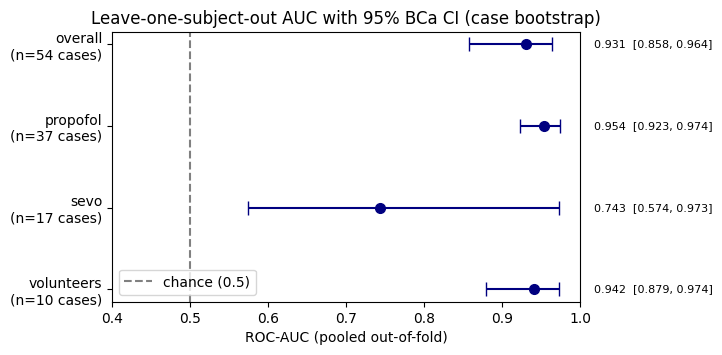

In [ ]:
# (a) Forest plot: AUC point estimate +/- 95% BCa CI per slice
plot_df = res.dropna(subset=["auc"]).reset_index(drop=True)
ypos = numpy.arange(len(plot_df))
yerr = numpy.vstack([
    plot_df["auc"] - plot_df["ci_low"],
    plot_df["ci_high"] - plot_df["auc"],
])

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.errorbar(plot_df["auc"], ypos, xerr=yerr, fmt="o", color="navy",
            capsize=5, markersize=7)
ax.axvline(0.5, color="grey", linestyle="--", label="chance (0.5)")
ax.set_yticks(ypos)
ax.set_yticklabels([f"{r.slice}\n(n={r.n_cases} cases)" for r in plot_df.itertuples()])
ax.set_xlabel("ROC-AUC (pooled out-of-fold)")
ax.set_title("Leave-one-subject-out AUC with 95% BCa CI (case bootstrap)")
ax.set_xlim(0.4, 1.0)
ax.invert_yaxis()
ax.legend(loc="lower left")

for r, yy in zip(plot_df.itertuples(), ypos):
    ax.text(1.03, yy, f"{r.auc:.3f}  [{r.ci_low:.3f}, {r.ci_high:.3f}]",
            transform=ax.get_yaxis_transform(), va="center", ha="left",
            fontsize=8, clip_on=False)
fig.subplots_adjust(left=0.18, right=0.70)
plt.show()

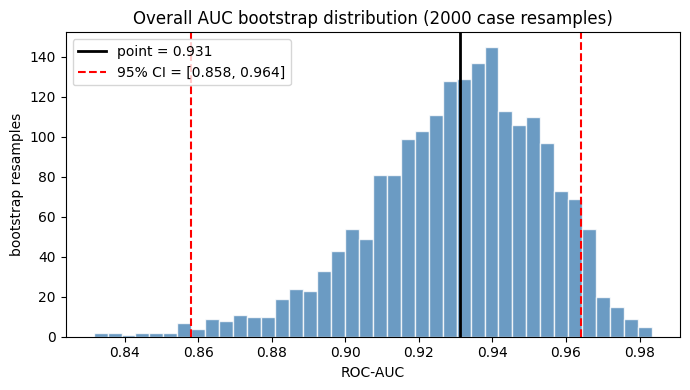

In [9]:
# (b) Bootstrap distribution of the overall-slice AUC
overall = res[res["slice"] == "overall"].iloc[0]
boots = boot_dists["overall"]
boots = boots[numpy.isfinite(boots)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(boots, bins=40, color="steelblue", alpha=0.8, edgecolor="white")
ax.axvline(overall["auc"], color="black", linewidth=2, label=f"point = {overall['auc']:.3f}")
ax.axvline(overall["ci_low"], color="red", linestyle="--", label=f"95% CI = [{overall['ci_low']:.3f}, {overall['ci_high']:.3f}]")
ax.axvline(overall["ci_high"], color="red", linestyle="--")
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("bootstrap resamples")
ax.set_title(f"Overall AUC bootstrap distribution ({len(boots)} case resamples)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. (Optional) literal "30 runs" view

Set `RUN_30 = True` to run the leave-one-subject-out pass 30 times, each time **re-tuning** the SVM with a different seed. This is the only genuinely stochastic knob in the pipeline, so the spread of the 30 pooled AUCs reflects hyperparameter-tuning instability rather than sampling uncertainty. **Expensive** (~30 hyperparameter searches); off by default.

In [10]:
RUN_30 = False

if RUN_30:
    overall_mask = masks["overall"]
    aucs_30 = []
    for run in range(30):
        p, _ = S.tune_one_set(X, y, groups, n_iter=N_ITER, seed=1000 + run)
        oof_run = numpy.full(len(y), numpy.nan)
        for tr, te in logo.split(X, y, groups):
            m = S.build_pipeline(p)
            m.fit(X[tr], y[tr])
            oof_run[te] = m.decision_function(X[te])
        a = S._safe_auc(y[overall_mask], oof_run[overall_mask])
        aucs_30.append(a)
        print(f"run {run + 1:2d}/30  overall AUC = {a:.4f}")

    aucs_30 = numpy.array(aucs_30)
    lo30, hi30 = numpy.percentile(aucs_30, [2.5, 97.5])
    print(f"\n30-run overall AUC: mean={aucs_30.mean():.4f}  std={aucs_30.std():.4f}")
    print(f"2.5-97.5 percentile interval: [{lo30:.4f}, {hi30:.4f}]")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(aucs_30, bins=15, color="darkorange", alpha=0.8, edgecolor="white")
    ax.axvline(aucs_30.mean(), color="black", linewidth=2, label=f"mean = {aucs_30.mean():.3f}")
    ax.axvline(lo30, color="red", linestyle="--", label=f"[{lo30:.3f}, {hi30:.3f}]")
    ax.axvline(hi30, color="red", linestyle="--")
    ax.set_xlabel("overall ROC-AUC")
    ax.set_ylabel("runs")
    ax.set_title("30 re-tuned leave-one-subject-out runs")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("RUN_30 is False - skipping the 30-run re-tune section.")

RUN_30 is False - skipping the 30-run re-tune section.
